In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import pandas as pd
from JobParameters import AerodynamicParameters, AcousticParameters
from Propeller import Propeller
import aerosandbox as asb

with open("../Datasets/Propellers/10x7E.pkl", "rb") as f:
    blade_dict = pickle.load(f)

aerodynamic_params = AerodynamicParameters(
    prop_radius=blade_dict['tip_radius'],
    hub_radius=blade_dict['hub_radius'],
    n_blades=blade_dict['n_blades'],
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
)

acoustic_params = AcousticParameters(
    aero_params=aerodynamic_params,
    p_ref=2e-5, revolutions=50, num_obs_times_per_rev=300
)

section_airfoils = [asb.Airfoil(coordinates=af) for af in blade_dict['airfoil']]

In [2]:
propeller = Propeller(
    propeller_geometry=blade_dict,
    aero_params=aerodynamic_params,
    acoustic_params=acoustic_params
)
v_inf = 0
propeller.run_bemt(v_inf=v_inf)

In [3]:
def prandtlLoss(phi, r):
    B = aerodynamic_params.n_blades

    f_tip = B * (aerodynamic_params.prop_radius - r) / (2 * r * np.sin(phi))
    f_hub = B * (r - aerodynamic_params.hub_radius) / (2 * r * np.sin(phi))

    # Clip to avoid overflow
    f_tip = np.clip(f_tip, 0.0, 500.0)
    f_hub = np.clip(f_hub, 0.0, 500.0)

    F_tip = 2 * np.arccos(np.exp(-f_tip)) / np.pi
    F_hub = 2 * np.arccos(np.exp(-f_hub)) / np.pi

    return F_tip * F_hub

In [4]:
from TurbulenceGenerator import TurbulenceGenerator

Ly, Lz = 0.3, 0.3     
Lx = 2 * propeller.solution_data.u.values.mean() * propeller.acoustic_params.revolutions * 60 / propeller.aero_params.rpm             

ny, nz = 100, 100
nx = int(100 * Lx)

sigma = 1  # Turbulence intensity (m/s)         
# L_scale: Set to 1/2 of diameter to see spatial variation across blades
L_scale = propeller.aero_params.prop_radius / 2       

turbulence_generator = TurbulenceGenerator(
    Lx=Lx,
    Ly=Ly,
    Lz=Lz,
    nx=nx,
    ny=ny,
    nz=nz,
    sigma=sigma,
    L_scale=L_scale,
    device='cuda'
)

u_box = turbulence_generator.generate_turbulence()

nx, ny, nz = u_box.shape

In [5]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator

aero_caches = [{} for _ in range(len(blade_dict['r']))]

def get_cache_key(alpha, Re, Ma):
    return (round(alpha, 3), round(Re, -4), round(Ma, 1))

x_coords = np.linspace(0, Lx, nx)
y_coords = np.linspace(-Ly/2, Ly/2, ny)
z_coords = np.linspace(-Lz/2, Lz/2, nz)
interp_u = RegularGridInterpolator((x_coords, y_coords, z_coords), u_box,
                                     bounds_error=False, fill_value=0)

In [6]:
# --- 1. PRE-ALLOCATION ---
n_stations = len(blade_dict['r'])
n_blades = aerodynamic_params.n_blades

_tables = [{} for _ in range(n_stations)]

dt = np.diff(propeller.acoustic_params.src_times)[0]
time_steps = len(propeller.acoustic_params.src_times)
history = {
    'alpha': np.zeros((time_steps, n_blades, n_stations)),
    'phi':   np.zeros((time_steps, n_blades, n_stations)),
    'W':     np.zeros((time_steps, n_blades, n_stations)),
    'cl':    np.zeros((time_steps, n_blades, n_stations)),
    'cd':    np.zeros((time_steps, n_blades, n_stations)),
    'vi':    np.zeros((time_steps, n_blades, n_stations)),
    'vt':    np.zeros((time_steps, n_blades, n_stations)),
    'dT':    np.zeros((time_steps, n_blades, n_stations)),
    'dQ':    np.zeros((time_steps, n_blades, n_stations)),
    'Re':    np.zeros((time_steps, n_blades, n_stations)),
    'Ma':    np.zeros((time_steps, n_blades, n_stations)),
}

# Global totals (1D arrays)
thrust_history = np.zeros(time_steps)
torque_history = np.zeros(time_steps)

x_accum = 0.0
modelSize = 'xxxlarge'
initial_phi = propeller.solution_data.phi.values

# --- 2. SIMULATION LOOP ---
for time_idx, t in enumerate(propeller.acoustic_params.src_times):
    n_iters = int(np.interp(time_idx, [0, 100], [5, 1]))
    # Advection

    v_advection = np.mean(history['vi'][time_idx-1]) if time_idx > 0 else 0
    x_accum += v_advection * dt
    x_plane = x_accum % Lx 
    
    T_ts = 0
    Q_ts = 0
    
    for b in range(n_blades):
        psi = (aerodynamic_params.omega * t) + (b * 2 * np.pi / n_blades)
        
        for i in range(n_stations):
            r = blade_dict['r'][i]
            dr = blade_dict['dr'][i]
            chord = blade_dict['chord'][i]
            omega_r = aerodynamic_params.omega * r
            
            # Sample Turbulence
            y_pos, z_pos = r * np.cos(psi), r * np.sin(psi)
            u_gust = interp_u([x_plane, y_pos, z_pos])[0]

            # Current Induction (from states)
            vI, vT = history['vi'][time_idx-1, b, i] if time_idx > 0 else initial_phi[i], history['vt'][time_idx-1, b, i] if time_idx > 0 else initial_phi[i]
            for iter in range(n_iters):
                # --- BEMT CALCULATIONS ---
                phi = np.arctan2(vI, vT)
                alpha = blade_dict['twist'][i] - np.degrees(phi)
                W = np.sqrt(vI**2 + vT**2)
                
                # Reynolds/Mach
                Re = aerodynamic_params.rho * W * chord / aerodynamic_params.mu
                Ma = W / aerodynamic_params.a_inf
                
                ReBin = round(Re, -4)
                MaBin = round(Ma, 1)
                key = (ReBin, MaBin)

                # Lazily build the CL/CD vs alpha table for this (ReBin, MaBin)
                if key not in _tables[i]:
                    # Alpha grid in degrees for tabulation
                    alpha_grid = np.linspace(-30.0, 40.0, 141)
                    full_output = asb.Airfoil.get_aero_from_neuralfoil(section_airfoils[i], alpha=alpha_grid, Re=ReBin, mach=MaBin, model_size=modelSize)
                    cl_grid = np.asarray(full_output["CL"], dtype=float)
                    cd_grid = np.asarray(full_output["CD"], dtype=float)
                    _tables[i][key] = (alpha_grid, cl_grid, cd_grid)

                alpha_grid, cl_grid, cd_grid = _tables[i][key]
                # 1D linear interpolation in alpha (degrees)
                cL = np.interp(alpha, alpha_grid, cl_grid)
                cD = np.interp(alpha, alpha_grid, cd_grid)
                if np.isnan(cL) or np.isnan(cD):
                    full_output = asb.Airfoil.get_aero_from_neuralfoil(section_airfoils[i], alpha=alpha, Re=Re, mach=Ma, model_size=modelSize)
                    cL, cD = full_output["CL"].item(), full_output["CD"].item()

                cLPrime = cL * np.cos(phi) - cD * np.sin(phi)
                cDPrime = cL * np.sin(phi) + cD * np.cos(phi)
                
                F = np.clip(prandtlLoss(phi, r), 1e-5, 1.0)
                sigma = aerodynamic_params.n_blades * chord / (2 * np.pi * r)
                k_t = sigma * cLPrime / (4 * F * np.sin(phi) * np.cos(phi)) 
                k_q = sigma * cDPrime / (4 * F * np.sin(phi) * np.cos(phi))
                aPrime = k_q / (1 + k_q)
                vI_new = aerodynamic_params.omega * r * k_t / (1 + k_q) + v_inf + u_gust
                vT_new = aerodynamic_params.omega * r * (1 - aPrime)

                vI += 0.7 * (vI_new - vI)
                vT += 0.7 * (vT_new - vT)

            # --- RECORD TO HISTORY ---
            history['alpha'][time_idx, b, i] = alpha
            history['phi'][time_idx, b, i]   = phi
            history['W'][time_idx, b, i]     = W
            history['cl'][time_idx, b, i]    = cL
            history['cd'][time_idx, b, i]    = cD
            history['vi'][time_idx, b, i]    = vI
            history['vt'][time_idx, b, i]    = vT
            history['Re'][time_idx, b, i]    = Re
            history['Ma'][time_idx, b, i]    = Ma

            dT = 0.5 * aerodynamic_params.rho * W**2 * chord * cLPrime * dr
            dQ = 0.5 * aerodynamic_params.rho * W**2 * chord * cDPrime * r * dr
            
            history['dT'][time_idx, b, i] = dT
            history['dQ'][time_idx, b, i] = dQ
            
            T_ts += dT
            Q_ts += dQ

    thrust_history[time_idx] = T_ts
    torque_history[time_idx] = Q_ts
    
    print(f"Time {t:.3f}s | Total Thrust: {T_ts:.4f}N")

KeyboardInterrupt: 

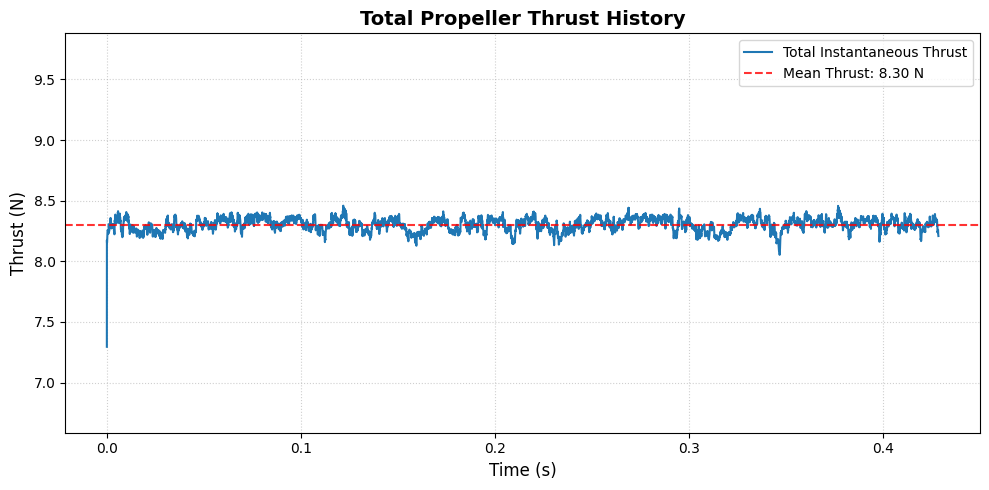

In [ ]:
import matplotlib.pyplot as plt

time_axis = np.arange(time_steps) * dt

# --- 2. PLOT ---
plt.figure(figsize=(10, 5), dpi=100)

# Plot the instantaneous total thrust
plt.plot(time_axis, thrust_history, 
         color='#1f77b4', 
         label='Total Instantaneous Thrust', 
         lw=1.5)

# Plot the mean thrust line for reference
plt.axhline(y=np.mean(thrust_history), 
            color='red', 
            linestyle='--', 
            label=f'Mean Thrust: {np.mean(thrust_history):.2f} N',
            alpha=0.8)

# Formatting
plt.title('Total Propeller Thrust History', fontsize=14, fontweight='bold')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Thrust (N)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.ylim(0.8*propeller.compute_total_forces()[0], 1.2*propeller.compute_total_forces()[0])

plt.tight_layout()
plt.show()